In [92]:
#Importando bibliotecas nescessarias
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import seaborn as sns
import matplotlib.pyplot as plt

In [93]:
#Carregando os dados
casas = fetch_california_housing(as_frame = True)
df = casas.frame
print("Primeiras 5 linhas do dataset")
print(df.head())

#Separando x(dados) y(alvo)
X = casas.data
y = casas.target
print(X.shape, y.shape)
print("20,640 amostras com 8 características + o valor medio")

print(casas.feature_names)


Primeiras 5 linhas do dataset
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
(20640, 8) (20640,)
20,640 amostras com 8 características + o valor medio
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [94]:
#Separando o dataset para treino e para teste
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=13)
print(X_train.shape, X_test.shape)

(16512, 8) (4128, 8)


Nota: A Análise Exploratória de Dados (EDA) e as visualizações estatísticas abaixo foram realizadas exclusivamente sobre o conjunto de treino para evitar vazamento de informação analítica (Data Leakage) e preservar a integridade do conjunto de teste como avaliação cega.

Valor maximo de uma casa em centenas de dolares: 5.00001


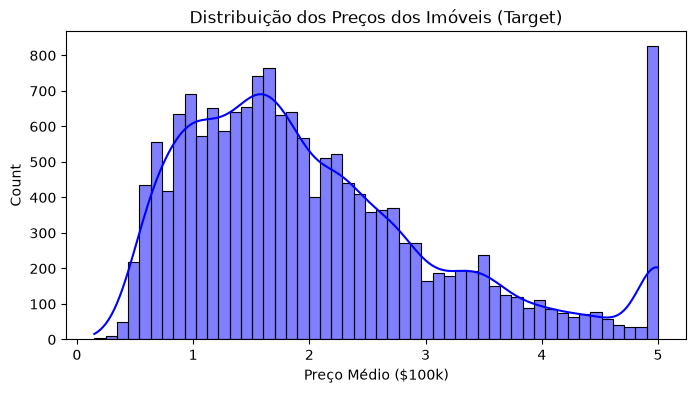

In [95]:
#Comportamento da variavel alvo
print(f"Valor maximo de uma casa em centenas de dolares: {y_train.max()}")
plt.figure(figsize=(8,4))
sns.histplot(y_train, kde=True, bins=50, color="blue")
plt.title('Distribuição dos Preços dos Imóveis (Target)')
plt.xlabel('Preço Médio ($100k)')
plt.show()

A análise do comportamento do vetor-alvo indica duas coisas principais:

Entre 300k e 500k, existe uma queda na quantidade de casas com esse valor, fator normal no mundo imobiliário, onde existem muitas casas baratas e, conforme o preço sobe, a quantidade de casas diminui drasticamente.

Em relação ao grande pico em 500k, estudando a origem do dataset, descobre-se que, no censo americano de 1990 (data e origem desses dados), havia um teto programado onde qualquer imóvel com preço maior que US$ 500.001 era registrado como US$ 500.001. Esse pico artificial é um problema para o algoritmo, pois, ao tentar prever uma mansão de US$ 1 milhão, por exemplo, o modelo resultaria em um preço próximo a 500k, pois é assim que imóveis semelhantes foram tratados nesse dataset.

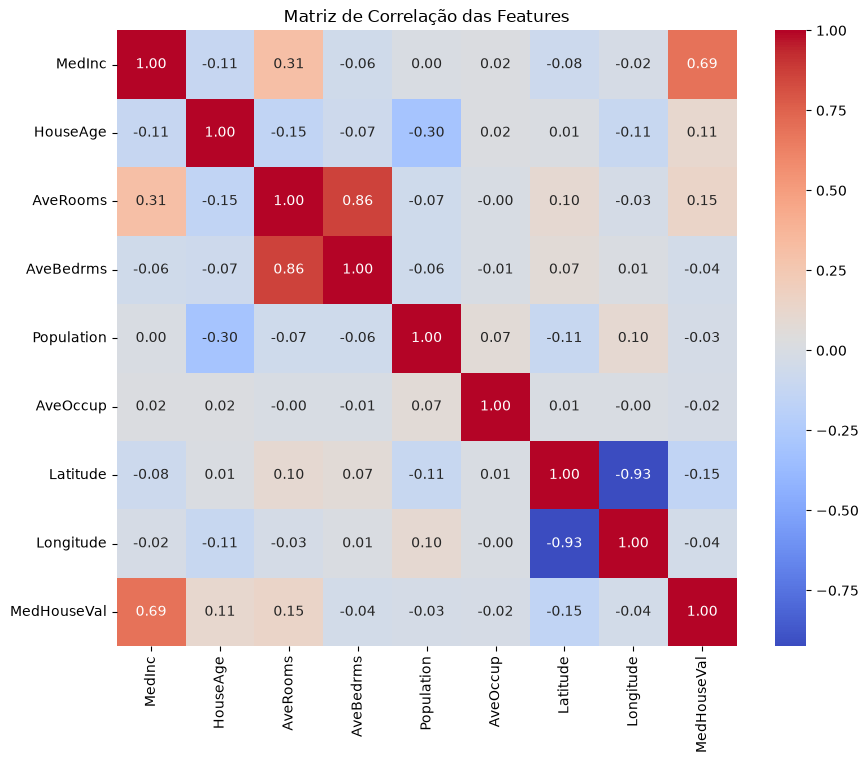

In [96]:
#Analisando quais features tem mais impacto no preco
df_train = pd.DataFrame(X_train, columns=casas.feature_names)
df_train['MedHouseVal'] = y_train

plt.figure(figsize=(10,8))
sns.heatmap(df_train.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação das Features")
plt.show()

Através da análise da Matriz de Correlação no conjunto de treino, percebe-se uma forte correlação linear positiva de 0.69 entre Renda Média (MedInc) e Valor do Imóvel (MedHouseVal), justificando a adequação do uso de modelos de Regressão Linear para este problema. Além disso, foi observada forte colinearidade entre o número de cômodos e o número de quartos (0.86).


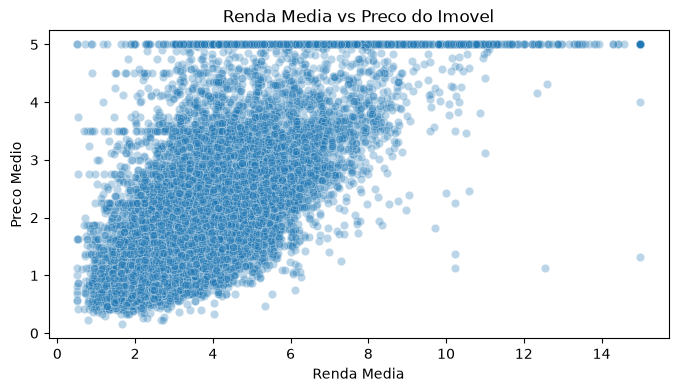

In [97]:
#Analizando linearidade em relacao a feature mais significativa

plt.figure(figsize=(8,4))
sns.scatterplot(x=df_train['MedInc'], y=df_train['MedHouseVal'], alpha = 0.3)
plt.title("Renda Media vs Preco do Imovel")
plt.xlabel("Renda Media")
plt.ylabel("Preco Medio")
plt.show()

Como o gráfico apresenta uma dispersão em formato de nuvem com inclinação diagonal ascendente, valida-se a relação linear positiva entre as variáveis, justificando o uso da Regressão Linear. Além disso, é possível notar a presença de alguns outliers, confirmar visualmente o problema do teto artificial de preço fixado em $500k (linha horizontal no topo do gráfico) e perceber especies de "linhas de corte", após pesquisa sobre o dataset é  possivel concluir que essas linhas ocorrem pois muitos analistas simplesmente arredondaram os preços das casas para valores fechados como 250k e 350k.

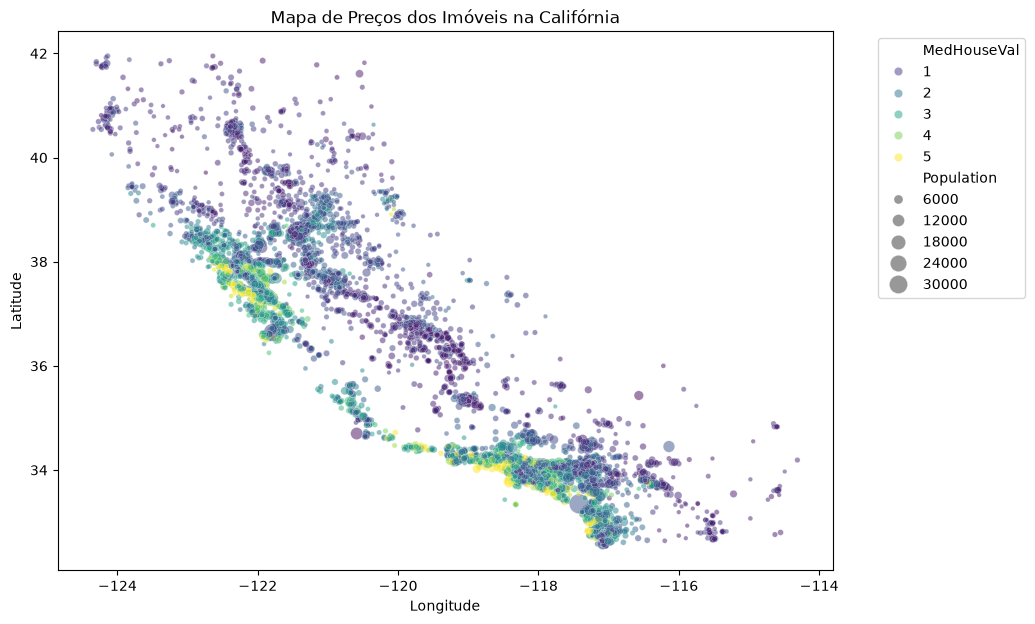

In [98]:
#Gráfico Geográfico
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=df_train['Longitude'], 
    y=df_train['Latitude'], 
    size=df_train['Population'], 
    hue=df_train['MedHouseVal'], 
    palette='viridis', 
    alpha=0.5,
    sizes=(10, 200)
)
plt.title('Mapa de Preços dos Imóveis na Califórnia')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

Esse gráfico geográfico mostra o mapa da Califórnia e com base nisso percebe-se que os imóveis mais caros ficam concentrados no litoral, em cidades como São Francisco e Los Angeles, enquanto no interior os imóveis são bem mais baratos.

In [99]:
# Seleção de Atributos: Removendo variável redundante por alta multicolinearidade
colunas_para_remover = ['AveBedrms']

X_train = X_train.drop(columns=colunas_para_remover)
X_test = X_test.drop(columns=colunas_para_remover)

print("Shape do Treino após remoção:", X_train.shape)
print("Shape do Teste após remoção:", X_test.shape)

Shape do Treino após remoção: (16512, 7)
Shape do Teste após remoção: (4128, 7)


Seleção de Atributos - Tratamento de Multicolinearidade: Durante a Análise Exploratória, identifiquei uma forte colinearidade (r = 0.86) entre as variáveis AveRooms (Média total de cômodos) e AveBedrms (Média de dormitórios). A presença de atributos altamente correlacionados em modelos de Regressão Linear distorce a estimação dos coeficientes (beta) e inflaciona a variância do modelo (Multicolinearidade). Analisando a correlação com a variável alvo (MedHouseVal), constatou-se que AveRooms possui maior poder explicativo (r = 0.15) em comparação com AveBedrms (r = -0.04). Portanto, a variável AveBedrms foi removida dos conjuntos de treino e teste para simplificar a arquitetura do modelo e garantir a estabilidade matemática da regressão.

In [100]:
#Padronizando as escalas dos dados
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

In [101]:
#Implementando o modelo de regressao linear
modelo = LinearRegression().fit(X_train_norm, y_train)
colunas_treinadas = ['MedInc', 'HouseAge', 'AveRooms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

# Criando uma tabela para visualizar a importância de cada variável
importancia_features = pd.DataFrame({
    'Feature': colunas_treinadas,
    'Peso (Coeficiente)': modelo.coef_
}).sort_values(by='Peso (Coeficiente)', ascending=False)

print(f"Bias (Preço Médio Base): {modelo.intercept_:.4f}\n")
display(importancia_features)

Bias (Preço Médio Base): 2.0674



,Feature,Peso (Coeficiente)
0,MedInc,0.699114
1,HouseAge,0.124996
2,AveRooms,0.045789
3,Population,-0.006101
4,AveOccup,-0.036560
6,Longitude,-0.931909
5,Latitude,-0.985858


A padronização dos dados via `StandardScaler` permite comparar diretamente os pesos atribuídos a cada variável, revelando quais fatores têm maior relevância matemática no cálculo do preço final dos imóveis:

b = 2.0674: Representa o preço médio-base do modelo. Quando todas as variáveis padronizadas se encontram na média (valor 0), a previsão inicial do imóvel é de aproximadamente 206.740.

MedInc = 0.6991: A Renda Média da vizinhança é a característica que mais impacta positivamente a valorização do imóvel. A magnitude elevada do coeficiente comprova que o poder aquisitivo da região é o principal motor de preços no dataset.

Latitude = -0.9859 / Longitude = -0.9319: Apresentam alto impacto em módulo (valor absoluto), evidenciando a forte dependência geográfica dos preços na Califórnia. Como as áreas mais caras estão concentradas no litoral e em coordenadas específicas, o modelo atribui pesos negativos expressivos para ajustar o preço conforme a distância desses centros de alto valor.

HouseAge = 0.1250  AveRooms = 0.0458: A idade da residência e o número médio de cômodos exercem uma influência positiva leve na valorização, atuando como refinamentos após a renda e a localização.

Population = -0.0061: Com um coeficiente virtualmente igual a zero, o tamanho da população local demonstra não influenciar a precificação, tornando-se um candidato forte à remoção em rodadas futuras de otimização do modelo.

In [102]:
#Gerando as previsões com o modelo treinado
y_pred = modelo.predict(X_test_norm)

#Calculando as métricas estatísticas
r2 = r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))

tabela_metricas = pd.DataFrame({
    'Métrica': [
        'R² Score', 
        'MAE (Erro Médio Absoluto)', 
        'RMSE (Raiz do Erro Quadrático)'
    ],
    'Valor Bruto': [r2, mae, rmse],
    'Significado no Negócio (Dólares / %)': [
        f'{r2 * 100:.2f}% da variação dos preços é explicada',
        f'Erro médio de ± ${mae * 100000:,.2f} por casa',
        f'Erro com penalidade para desvios altos: ± ${rmse * 100000:,.2f}'
    ]
})

print("=== AVALIAÇÃO DO MODELO NO CONJUNTO DE TESTE ===")
display(tabela_metricas)

=== AVALIAÇÃO DO MODELO NO CONJUNTO DE TESTE ===


,Métrica,Valor Bruto,Significado no Negócio (Dólares / %)
0,R² Score,0.595228,59.52% da variação dos preços é explicada
1,MAE (Erro Médio Absoluto),0.551583,"Erro médio de ± $55,158.29 por casa"
2,RMSE (Raiz do Erro Quadrático),0.738585,"Erro com penalidade para desvios altos: ± $73,..."


Avaliação de Desempenho e Diagnóstico de Resíduos

O modelo de Regressão Linear foi avaliado no conjunto de teste 20\% dos dados, totalmente invisíveis durante o treino, apresentando os seguintes indicadores de performance:

Poder Explicativo R^2 = 0.5952$: O modelo é capaz de explicar 59.52% da variância dos preços dos imóveis na Califórnia. Este patamar reflete o limite de desempenho de modelos paramétricos lineares sobre o dataset, dado que características geográficas e socioeconômicas frequentemente exibem comportamentos não-lineares.

Precisão Cotidiana MAE = $55,158.29: O Erro Médio Absoluto indica que, na estimativa regular de preços de blocos habitacionais, a previsão do modelo diverge da realidade por volta de ± $55.158 dólares.

Sensibilidade a Valores Extremos RMSE = $73,858.45: O desvio superior do RMSE em relação ao MAE evidencia a presença de erros de alta magnitude em pontos específicos do conjunto de teste.

Conexão com a Análise Exploratória (EDA)
A diferença entre o RMSE ($73.8k) e o MAE ($55.1k) confirma quantitativamente os diagnósticos levantados durante a fase de EDA:

1. Efeito do Teto de R$ 500k: Em vizinhanças de alta renda, o modelo prevê valores coerentes com a tendência de mercado (superior a $500k), mas é penalizado por confrontar o limite artificial truncado pela coleta original dos dados.

2. Escassez de Variáveis Estruturais: A ausência de dados granulares sobre a qualidade ou acabamento dos imóveis impede o modelo de diferenciar residências de luxo de residências comuns em uma mesma faixa de renda média.

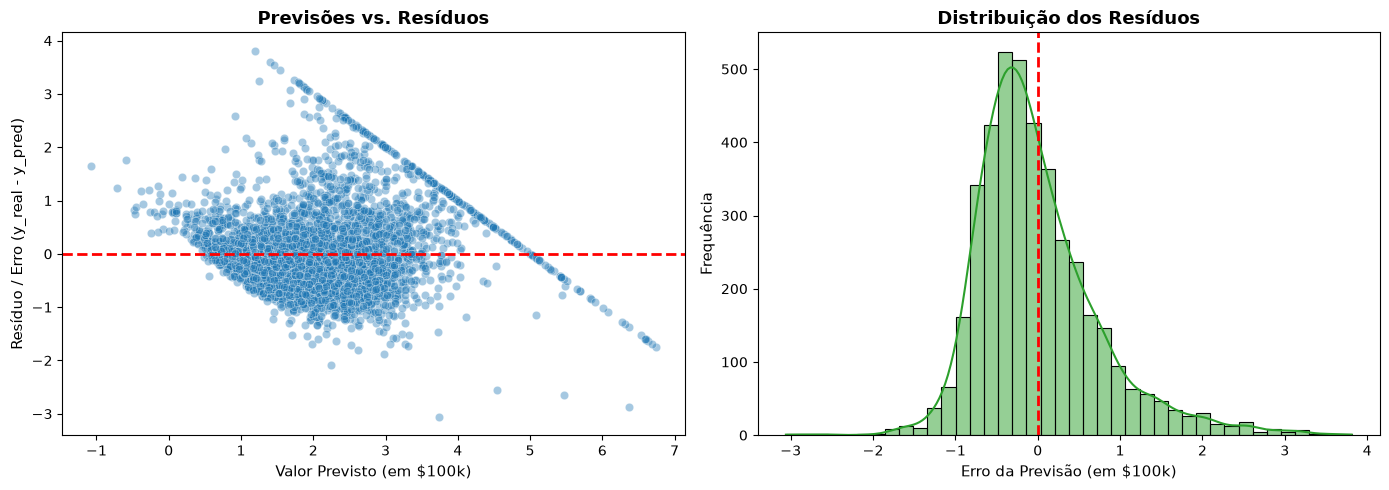

<Figure size 640x480 with 0 Axes>

In [ ]:
# Calculando os resíduos (Erro = Valor Real - Valor Previsto)
residuos = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Gráfico 1: Previsões vs. Resíduos
sns.scatterplot(
    x=y_pred, 
    y=residuos, 
    alpha=0.4, 
    color='#1f77b4', 
    ax=axes[0]
)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Previsões vs. Resíduos', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Valor Previsto (em $100k)', fontsize=11)
axes[0].set_ylabel('Resíduo / Erro (y_real - y_pred)', fontsize=11)

#Gráfico 2: Distribuição dos Resíduos
sns.histplot(residuos, kde=True, color='#2ca02c', bins=40, ax=axes[1])
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Distribuição dos Resíduos', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Erro da Previsão (em $100k)', fontsize=11)
axes[1].set_ylabel('Frequência', fontsize=11)

plt.tight_layout()
plt.show()

Diagnóstico Visual de Resíduos

A análise dos resíduos permite verificar se os erros do modelo seguem pressupostos estatísticos adequados ou se existem vieses sistemáticos nas previsões:

Simetria ao redor do Zero: A distribuição dos erros (gráfico à direita) apresenta formato quase normal e centrado em zero, demonstrando que o modelo é não-viesado (não erra sistematicamente apenas para cima ou apenas para baixo na média geral).

Artefato do Teto de 500k: No gráfico de dispersão à esquerda, é nitidamente visível uma linha de fronteira diagonal na borda superior. Esse padrão ocorre porque imóveis de alto valor (truncados em $500.000 no dataset original) geram resíduos lineares decrescentes conforme o modelo tenta prever seus valores reais acima do teto.

Homocedasticidade: Embora a nuvem de pontos esteja razoavelmente distribuída em torno da linha zero, nota-se uma leve dispersão maior nas previsões de valor mais alto, reforçando a limitação da regressão linear simples para capturar comportamentos complexos nas faixas mais caras de precificação.